# **Caso People Analytics VI: Clustering de Empleados**

En este caso práctico trabajaremos con un dataset simulado de aproximadamente 600 empleados de una empresa. El objetivo es aplicar técnicas de People Analytics para descubrir si existen grupos naturales de empleados con características similares.

El dataset incluye información relacionada con el perfil profesional y el comportamiento laboral de los empleados, como por ejemplo:

- Departamento.

- Nivel de seniority.

- Si el empleado es manager o no.

- Edad y antigüedad en la empresa.

- Salario.

- Performance y engagement.

- Horas de formación.

- Absentismo.

- Promociones recientes.

Una vez preparados los datos, utilizaremos técnicas de clustering (aprendizaje no supervisado) para identificar segmentos de empleados dentro de la organización.

Estos segmentos pueden ayudar al área de Recursos Humanos a comprender mejor la estructura de la plantilla y a diseñar estrategias específicas de desarrollo, retención o formación para cada grupo de empleados.



In [1]:
# Primero importamos las librerias que vamos a usar

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

In [2]:
# Cargamos el dataset

url = "https://raw.githubusercontent.com/Pablolg87/people-analytics-case-06-Employees-Clustering/refs/heads/main/employee_clustering_dataset.csv"

employees = pd.read_csv(url)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Seguimos con un info, head y shape, para ver como es el dataset

employees.info()

employees.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        606 non-null    int64  
 1   Department         603 non-null    object 
 2   Seniority          604 non-null    object 
 3   Manager            606 non-null    int64  
 4   Age                606 non-null    int64  
 5   Tenure_Years       606 non-null    float64
 6   Salary_EUR         600 non-null    float64
 7   Performance_Score  601 non-null    float64
 8   Engagement_Score   598 non-null    float64
 9   Training_Hours     601 non-null    float64
 10  Absenteeism_Days   602 non-null    float64
 11  Promotion_Last_3Y  606 non-null    int64  
dtypes: float64(6), int64(4), object(2)
memory usage: 56.9+ KB


(606, 12)

In [5]:
employees.head(15)

,Employee_ID,Department,Seniority,Manager,Age,Tenure_Years,Salary_EUR,Performance_Score,Engagement_Score,Training_Hours,Absenteeism_Days,Promotion_Last_3Y
0,1,HR,Mid,0,41,3.4,50100.0,4.31,4.22,29.0,6.0,0
1,2,Product,Senior,0,34,7.2,80400.0,4.21,3.09,20.0,5.0,0
2,3,Finance,Lead,0,42,9.3,105100.0,3.94,3.28,26.0,3.0,0
3,4,Marketing,Senior,0,33,7.8,63800.0,3.03,3.49,30.0,4.0,0
4,5,Engineering,Director,1,44,6.2,130000.0,3.11,5.00,28.0,4.0,1
5,6,Customer Success,Senior,1,35,4.4,74200.0,4.02,3.81,36.0,1.0,0
6,7,HR,Lead,0,38,7.4,78800.0,3.02,4.34,36.0,6.0,0
7,8,HR,Junior,0,23,5.8,33400.0,3.56,4.24,66.0,4.0,0
8,9,Engineering,Senior,0,37,7.7,72400.0,3.84,3.81,32.0,6.0,0
9,10,Product,Mid,0,27,4.8,66400.0,3.09,2.80,50.0,2.0,0


Antes de aplicar los modelos de clustering, será necesario realizar un proceso de limpieza y preparación de los datos, ya que el dataset contiene intencionadamente algunos problemas comunes en proyectos reales de datos, como:

a) Valores nulos

b) Registros duplicados

c) Algunos valores inconsistentes

In [6]:
# Revisamos duplicados

employees.duplicated().sum()

np.int64(4)

In [7]:
# Los eliminamos

employees.drop_duplicates(inplace=True)

# Revisamos de nuevo

employees.duplicated().sum()

np.int64(0)

In [8]:
# Revisamos valores nulos

employees.isnull().sum()

,0
Employee_ID,0
Department,3
Seniority,2
Manager,0
Age,0
Tenure_Years,0
Salary_EUR,6
Performance_Score,5
Engagement_Score,8
Training_Hours,5


In [9]:
# Ponemos a 0 los días de absentismo, entendemos que si es nulo es 0

employees["Absenteeism_Days"] = employees["Absenteeism_Days"].fillna(0)

# Revisamos valores nulos en absentismo

employees["Absenteeism_Days"].isnull().sum()

np.int64(0)

In [10]:
# Con Engagement y Training Hours imputamos la mediana

employees["Engagement_Score"] = employees["Engagement_Score"].fillna(
    employees["Engagement_Score"].median()
)

employees["Training_Hours"] = employees["Training_Hours"].fillna(
    employees["Training_Hours"].median()
)

# Con Performance_Score imputamos la media

employees["Performance_Score"] = employees["Performance_Score"].fillna(
    employees["Performance_Score"].mean()
)

En otros casos debemos de ser más estratégicos:

- Con departamento, crearemos uno nuevo con los nulos: "Unknown"
- Salary: imputaremos la mediana del departamento correspondiente.
- Seniority: obtendremos esa información con la variable Tenure_years

In [11]:
# Department: imputar "Unknown" como categoría explícita
employees["Department"] = employees["Department"].fillna("Unknown")

# Seniority: imputar usando Tenure_Years
def infer_seniority_from_tenure(t):
    if pd.isna(t):
        return "Unknown"
    if t < 2:
        return "Junior"
    elif t < 5:
        return "Mid"
    elif t < 8:
        return "Senior"
    elif t < 12:
        return "Lead"
    else:
        return "Director"

employees["Seniority"] = employees["Seniority"].fillna(
    employees["Tenure_Years"].apply(infer_seniority_from_tenure)
)

# Salary: imputar con mediana del propio departamento
employees["Salary_EUR"] = pd.to_numeric(employees["Salary_EUR"], errors="coerce")

dept_median_salary = employees.groupby("Department")["Salary_EUR"].transform("median")
employees["Salary_EUR"] = employees["Salary_EUR"].fillna(dept_median_salary)

# Fallback global si sigue habiendo nulos
employees["Salary_EUR"] = employees["Salary_EUR"].fillna(
    employees["Salary_EUR"].median()
)

In [12]:
# Comprobamos nulos de nuevo

employees.isnull().sum()

,0
Employee_ID,0
Department,0
Seniority,0
Manager,0
Age,0
Tenure_Years,0
Salary_EUR,0
Performance_Score,0
Engagement_Score,0
Training_Hours,0


**Ahora vemos distribuciones de las variables:**

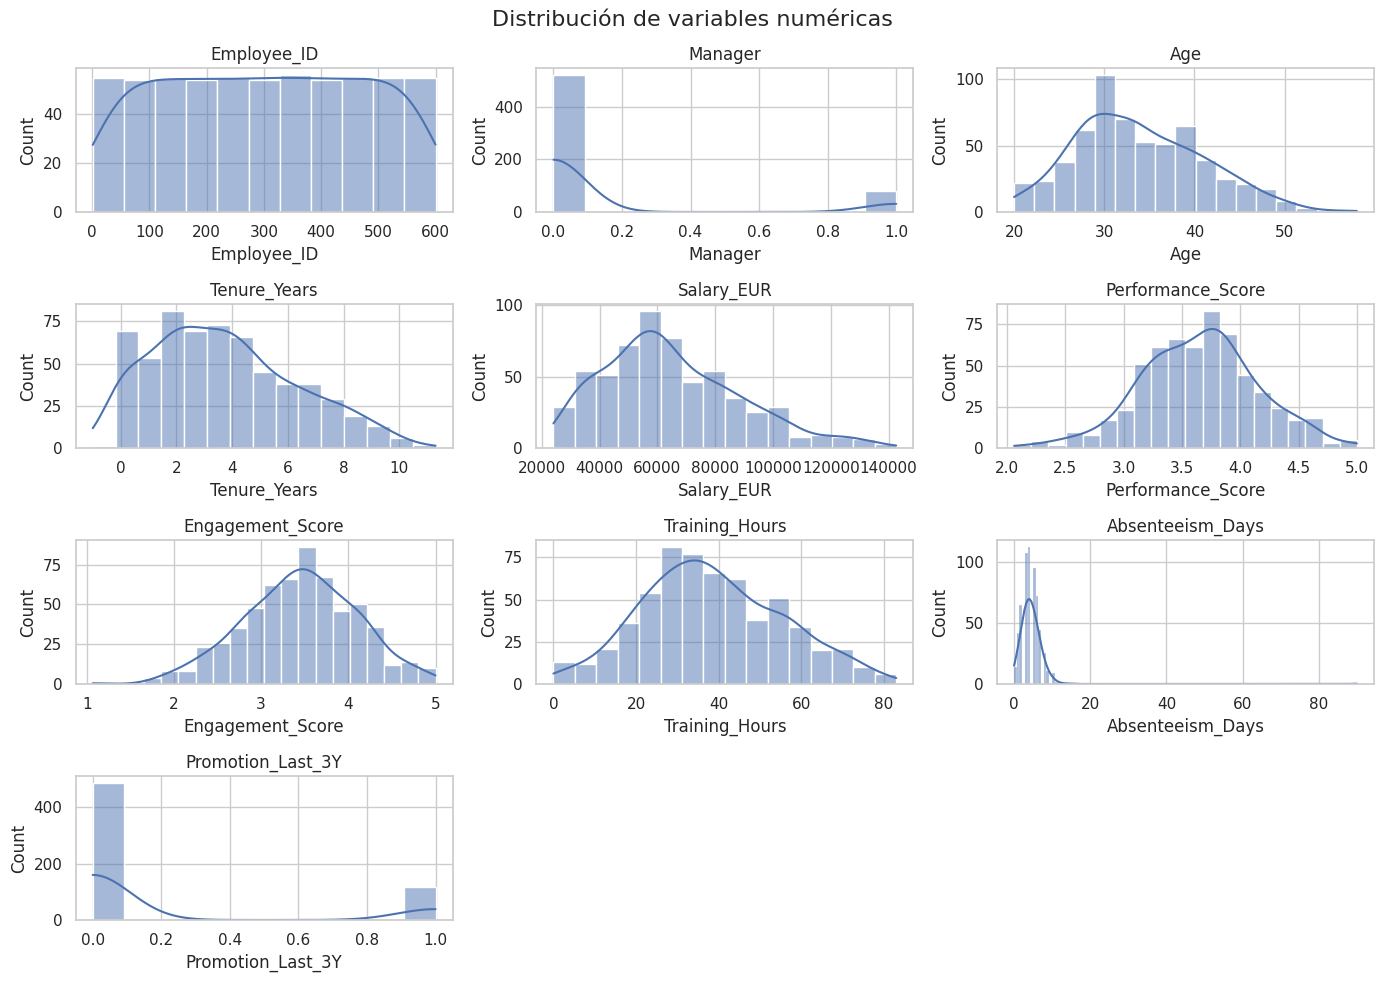

In [13]:
# Visualización de distribucion de cariables numéricas

num_cols = employees.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(14,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4,3,i)   # antes era 3,3
    sns.histplot(employees[col], kde=True)
    plt.title(col)

plt.suptitle("Distribución de variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

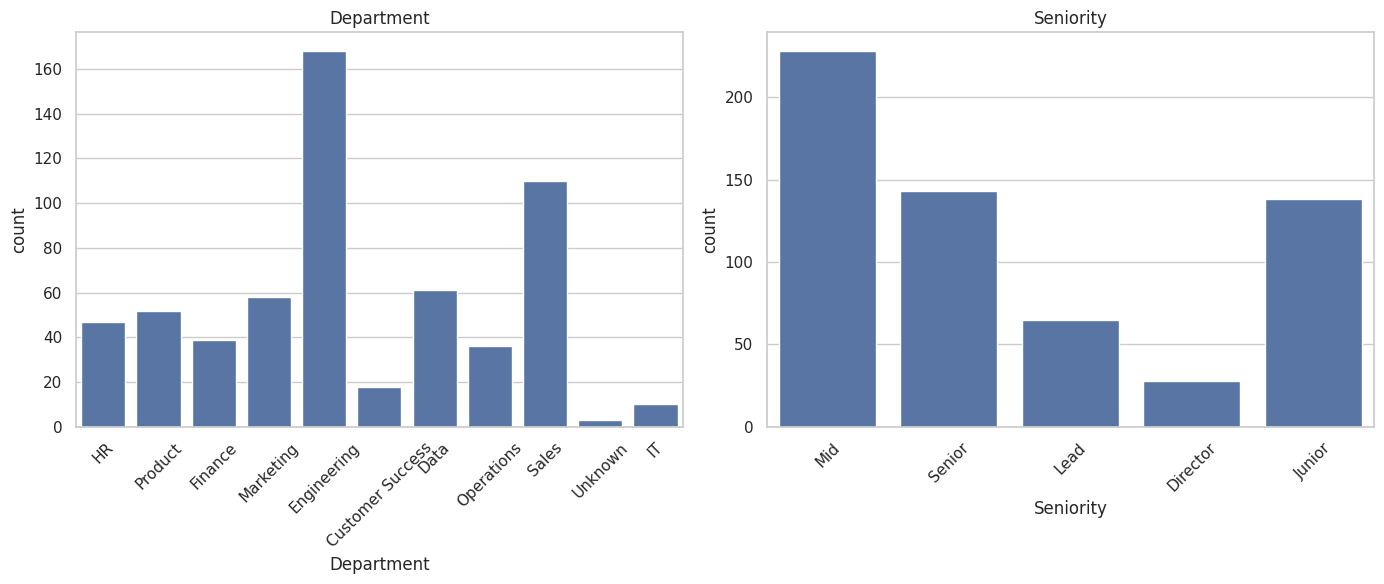

In [14]:
# Visualizamos distribución de variables categóricas
cat_cols = employees.select_dtypes(include=["object"]).columns

plt.figure(figsize=(14,6))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, len(cat_cols), i)
    sns.countplot(data=employees, x=col)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
# Eliminamos empleados con más de 50 días de absentismo y comprobamos el máximo
employees = employees[employees["Absenteeism_Days"] <= 50]

employees["Absenteeism_Days"].max()

15.0

In [16]:
# Revisamos de nuevo todo el dataset y vemos valores estadísticos básicos

employees.info()
employees.shape

<class 'pandas.core.frame.DataFrame'>
Index: 601 entries, 0 to 605
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        601 non-null    int64  
 1   Department         601 non-null    object 
 2   Seniority          601 non-null    object 
 3   Manager            601 non-null    int64  
 4   Age                601 non-null    int64  
 5   Tenure_Years       601 non-null    float64
 6   Salary_EUR         601 non-null    float64
 7   Performance_Score  601 non-null    float64
 8   Engagement_Score   601 non-null    float64
 9   Training_Hours     601 non-null    float64
 10  Absenteeism_Days   601 non-null    float64
 11  Promotion_Last_3Y  601 non-null    int64  
dtypes: float64(6), int64(4), object(2)
memory usage: 61.0+ KB


(601, 12)

In [17]:
employees.describe()

,Employee_ID,Manager,Age,Tenure_Years,Salary_EUR,Performance_Score,Engagement_Score,Training_Hours,Absenteeism_Days,Promotion_Last_3Y
count,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000
mean,301.016639,0.133111,33.835275,3.722795,64805.294509,3.652079,3.451547,38.615641,4.337770,0.194676
std,173.436597,0.339978,7.074213,2.570492,23728.543904,0.500851,0.650907,16.950232,2.251826,0.396281
min,1.000000,0.000000,20.000000,-1.000000,24000.000000,2.060000,1.070000,0.000000,0.000000,0.000000
25%,151.000000,0.000000,29.000000,1.800000,48100.000000,3.310000,3.030000,27.000000,3.000000,0.000000
50%,302.000000,0.000000,33.000000,3.500000,61000.000000,3.670000,3.470000,37.000000,4.000000,0.000000
75%,451.000000,0.000000,39.000000,5.400000,80000.000000,3.950000,3.900000,50.000000,6.000000,0.000000
max,600.000000,1.000000,58.000000,11.300000,142600.000000,5.000000,5.000000,83.000000,15.000000,1.000000


In [18]:
# Vamos a quitar Employee_ID, no nos aporta nada aqui

employees.drop(columns=["Employee_ID"], errors="ignore", inplace=True)

# Volvemos a revisar

employees.info()

<class 'pandas.core.frame.DataFrame'>
Index: 601 entries, 0 to 605
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Department         601 non-null    object 
 1   Seniority          601 non-null    object 
 2   Manager            601 non-null    int64  
 3   Age                601 non-null    int64  
 4   Tenure_Years       601 non-null    float64
 5   Salary_EUR         601 non-null    float64
 6   Performance_Score  601 non-null    float64
 7   Engagement_Score   601 non-null    float64
 8   Training_Hours     601 non-null    float64
 9   Absenteeism_Days   601 non-null    float64
 10  Promotion_Last_3Y  601 non-null    int64  
dtypes: float64(6), int64(3), object(2)
memory usage: 56.3+ KB


# **Preparación de los datos para el modelo de clustering**

Una vez limpio el dataset (tratamiento de valores nulos, eliminación de duplicados y revisión de distribuciones), el siguiente paso es preparar los datos para poder aplicar un modelo de clustering.

Los algoritmos de clustering trabajan únicamente con variables numéricas, por lo que antes de entrenar el modelo debemos realizar algunas transformaciones en el dataset:

- Eliminar variables que no aportan información al análisis, como los identificadores (por ejemplo, Employee_ID).

- Transformar las variables categóricas (como Department o Seniority) en variables numéricas mediante técnicas de encoding.

- Escalar las variables numéricas, ya que los algoritmos de clustering utilizan distancias entre observaciones y variables como el salario podrían dominar el cálculo si no se normalizan.

Una vez preparados los datos, aplicaremos un algoritmo de clustering (K-Means) para identificar grupos de empleados con características similares dentro de la empresa.

El **objetivo final es descubrir patrones o perfiles de empleados que puedan ser útiles para el análisis de la plantilla, desde una perspectiva de People Analytics.**

In [19]:
# Necesitamos convertir a numéricas las variables categóricas

# Usamos One-Hot Encoding

employees_encoded = pd.get_dummies(
    employees,
    columns=["Department", "Seniority"],
    drop_first=True
)

# Revisamos el resultado

employees_encoded.head()

,Manager,Age,Tenure_Years,Salary_EUR,Performance_Score,Engagement_Score,Training_Hours,Absenteeism_Days,Promotion_Last_3Y,Department_Data,...,Department_IT,Department_Marketing,Department_Operations,Department_Product,Department_Sales,Department_Unknown,Seniority_Junior,Seniority_Lead,Seniority_Mid,Seniority_Senior
0,0,41,3.4,50100.0,4.31,4.22,29.0,6.0,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,34,7.2,80400.0,4.21,3.09,20.0,5.0,0,False,...,False,False,False,True,False,False,False,False,False,True
2,0,42,9.3,105100.0,3.94,3.28,26.0,3.0,0,False,...,False,False,False,False,False,False,False,True,False,False
3,0,33,7.8,63800.0,3.03,3.49,30.0,4.0,0,False,...,False,True,False,False,False,False,False,False,False,True
4,1,44,6.2,130000.0,3.11,5.00,28.0,4.0,1,False,...,False,False,False,False,False,False,False,False,False,False


In [20]:
# Escalamos variables con escala estándar (Z-score)

scaler = StandardScaler()

# Escalamos las variables
X_scaled = scaler.fit_transform(employees_encoded)

# Convertimos el resultado a DataFrame para verlo mejor
X_scaled = pd.DataFrame(X_scaled, columns=employees_encoded.columns)

# Revisamos
X_scaled.head()

,Manager,Age,Tenure_Years,Salary_EUR,Performance_Score,Engagement_Score,Training_Hours,Absenteeism_Days,Promotion_Last_3Y,Department_Data,...,Department_IT,Department_Marketing,Department_Operations,Department_Product,Department_Sales,Department_Unknown,Seniority_Junior,Seniority_Lead,Seniority_Mid,Seniority_Senior
0,-0.391856,1.013638,-0.125682,-0.620246,1.314702,1.181571,-0.567759,0.738784,-0.491666,-0.3361,...,-0.130079,-0.326824,-0.252422,-0.304512,-0.473321,-0.070829,-0.545945,-0.348236,1.279048,-0.558773
1,-0.391856,0.023305,1.353866,0.657760,1.114876,-0.555914,-1.099168,0.294331,-0.491666,-0.3361,...,-0.130079,-0.326824,-0.252422,3.283948,-0.473321,-0.070829,-0.545945,-0.348236,-0.781831,1.789636
2,-0.391856,1.155115,2.171510,1.699568,0.575344,-0.263771,-0.744895,-0.594577,-0.491666,-0.3361,...,-0.130079,-0.326824,-0.252422,-0.304512,-0.473321,-0.070829,-0.545945,2.871612,-0.781831,-0.558773
3,-0.391856,-0.118171,1.587479,-0.042402,-1.243079,0.059125,-0.508714,-0.150123,-0.491666,-0.3361,...,-0.130079,3.059750,-0.252422,-0.304512,-0.473321,-0.070829,-0.545945,-0.348236,-0.781831,1.789636
4,2.551960,1.438067,0.964511,2.749811,-1.083217,2.380896,-0.626805,-0.150123,2.033901,-0.3361,...,-0.130079,-0.326824,-0.252422,-0.304512,-0.473321,-0.070829,-0.545945,-0.348236,-0.781831,-0.558773


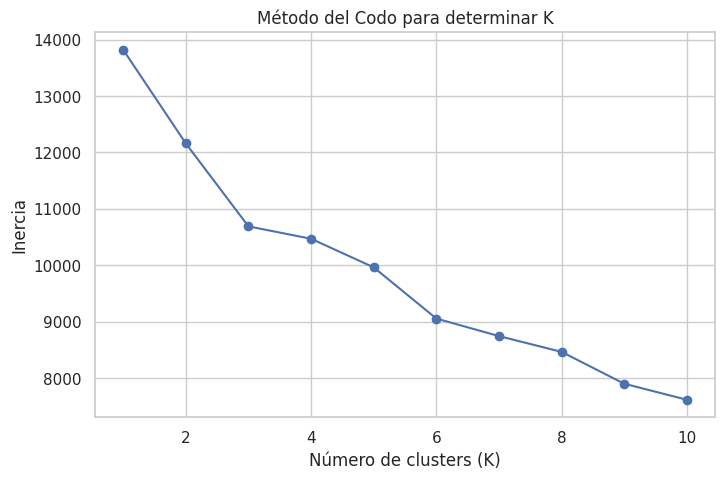

In [21]:
# Definimos cuantos clusters son los óptimos con el método del codo

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# gráfico
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo para determinar K")
plt.show()

La caída fuerte ocurre hasta K ≈ 3, y a partir de ahí la mejora es más gradual. Un punto razonable para empezar es K = 4 (equilibra compacidad y simplicidad).

In [22]:
# Entrenamos el modelo
kmeans = KMeans(n_clusters=4, random_state=42)

# Ajustamos y obtenemos las etiquetas
clusters = kmeans.fit_predict(X_scaled)

# Añadimos el cluster al dataset original para interpretarlo
employees["Cluster"] = clusters

# Revisión rápida
employees.head()

,Department,Seniority,Manager,Age,Tenure_Years,Salary_EUR,Performance_Score,Engagement_Score,Training_Hours,Absenteeism_Days,Promotion_Last_3Y,Cluster
0,HR,Mid,0,41,3.4,50100.0,4.31,4.22,29.0,6.0,0,3
1,Product,Senior,0,34,7.2,80400.0,4.21,3.09,20.0,5.0,0,3
2,Finance,Lead,0,42,9.3,105100.0,3.94,3.28,26.0,3.0,0,1
3,Marketing,Senior,0,33,7.8,63800.0,3.03,3.49,30.0,4.0,0,3
4,Engineering,Director,1,44,6.2,130000.0,3.11,5.00,28.0,4.0,1,2


In [23]:
employees["Cluster"].value_counts()

,count
Cluster,
3,324
0,128
2,110
1,39


Ahora evaluaremos qué tan bien están formados los clusters utilizando el **Silhouette Score.**

Esta métrica mide:

1) Qué tan similar es cada punto a su propio cluster.

2) Qué tan diferente es respecto a otros clusters.

In [24]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.1447404406979567


Los clusters no están muy bien separados, ya que esa variables es baja

**Score	Interpretación:**

a) >0.5	clusters muy claros

b) 0.3–0.5	buenos clusters

c) 0.2–0.3	clusters débiles

d) <0.2	clusters poco separados

Pero esto no es raro en People Analytics, porque:

- Hay muchas variables.

- Hay ruido en los datos.

- Los perfiles de empleados suelen solaparse.

Así que no invalida el análisis.

Antes de decidir definitivamente K, vamos a visualizar los clusters con PCA para ver si realmente existe separación entre grupos.

In [25]:
# Reducimos a 2 dimensiones
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Convertimos a dataframe
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])

# Añadimos cluster
pca_df["Cluster"] = clusters

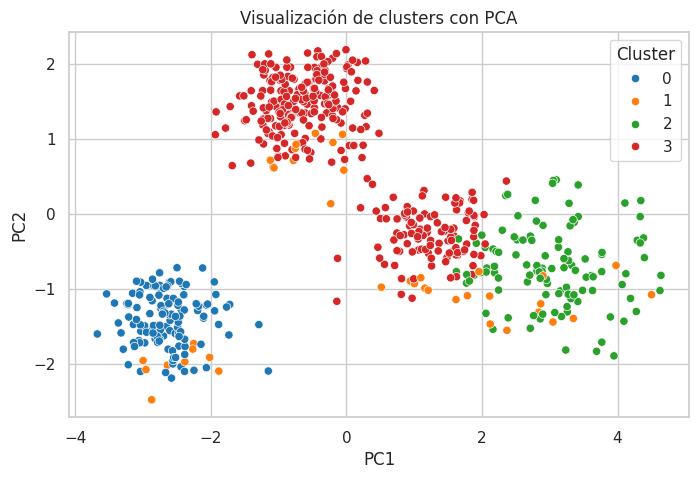

In [26]:
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10"
)

plt.title("Visualización de clusters con PCA")
plt.show()

Se observan 4 grupos relativamente claros:

**Cluster 0 (azul)**

- Muy compacto.
- Bien separado del resto.
- Grupo bastante homogéneo.

**Cluster 2 (verde)**

- También bastante compacto.
- Algo más disperso.
- Separación razonable.

**Cluster 3 (rojo)**

- Dos subzonas pero bastante densas.
- Probablemente empleados con características similares.

**Cluster 1 (naranja)**

- Pequeño.
- Mezclado con otros clusters.
- Podría ser empleados frontera o perfiles híbridos.

Aunque el Silhouette era bajo (~0.14), el PCA muestra que:

1) Sí existe estructura.

2) Hay grupos relativamente claros.

3) El modelo no es aleatorio.

Esto es muy típico en datos organizacionales.

Ahora toca **interpretar los clusters**, que es lo que realmente **importa en People Analytics.**

Queremos responder:

**¿Qué tipo de empleados hay en cada cluster?**

In [27]:
# Perfilado de CLusters

# Perfil numérico (medias por cluster)
cluster_means = employees.groupby("Cluster")[[
    "Age","Tenure_Years","Salary_EUR","Performance_Score",
    "Engagement_Score","Training_Hours","Absenteeism_Days",
    "Manager","Promotion_Last_3Y"
]].mean().round(2)

# Tamaño de cada cluster
cluster_size = employees["Cluster"].value_counts().sort_index().rename("Cluster_Size")

# Distribución de Department y Seniority por cluster (conteos y %)
dept_counts = pd.crosstab(employees["Cluster"], employees["Department"])
dept_perc = (dept_counts.div(dept_counts.sum(axis=1), axis=0) * 100).round(1)

sen_counts = pd.crosstab(employees["Cluster"], employees["Seniority"])
sen_perc = (sen_counts.div(sen_counts.sum(axis=1), axis=0) * 100).round(1)

# Output final
print("=== Tamaño de clusters ===")
print(cluster_size.to_string())
print("\n=== Medias numéricas por cluster ===")
display(cluster_means)

print("\n=== Department por cluster (conteos) ===")
display(dept_counts)

print("\n=== Department por cluster (%) ===")
display(dept_perc)

print("\n=== Seniority por cluster (conteos) ===")
display(sen_counts)

print("\n=== Seniority por cluster (%) ===")
display(sen_perc)

=== Tamaño de clusters ===
Cluster
0    128
1     39
2    110
3    324

=== Medias numéricas por cluster ===


,Age,Tenure_Years,Salary_EUR,Performance_Score,Engagement_Score,Training_Hours,Absenteeism_Days,Manager,Promotion_Last_3Y
Cluster,,,,,,,,,
0,26.66,1.48,37619.14,3.61,3.42,60.24,4.38,0.01,0.21
1,35.03,3.74,65661.54,3.74,3.38,36.08,3.54,0.13,0.31
2,43.11,6.74,99985.45,3.74,3.47,21.54,4.39,0.55,0.17
3,33.38,3.58,63498.56,3.63,3.47,36.18,4.40,0.04,0.18



=== Department por cluster (conteos) ===


Department,Customer Success,Data,Engineering,Finance,HR,IT,Marketing,Operations,Product,Sales,Unknown
Cluster,,,,,,,,,,,
0,2,16,38,0,9,2,15,11,8,27,0
1,0,0,0,39,0,0,0,0,0,0,0
2,3,19,32,0,9,2,12,4,9,18,2
3,13,26,98,0,29,6,31,21,34,65,1



=== Department por cluster (%) ===


Department,Customer Success,Data,Engineering,Finance,HR,IT,Marketing,Operations,Product,Sales,Unknown
Cluster,,,,,,,,,,,
0,1.6,12.5,29.7,0.0,7.0,1.6,11.7,8.6,6.2,21.1,0.0
1,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.7,17.3,29.1,0.0,8.2,1.8,10.9,3.6,8.2,16.4,1.8
3,4.0,8.0,30.2,0.0,9.0,1.9,9.6,6.5,10.5,20.1,0.3



=== Seniority por cluster (conteos) ===


Seniority,Director,Junior,Lead,Mid,Senior
Cluster,,,,,
0,0,128,0,0,0
1,2,10,5,10,12
2,25,0,60,0,25
3,0,0,0,218,106



=== Seniority por cluster (%) ===


Seniority,Director,Junior,Lead,Mid,Senior
Cluster,,,,,
0,0.0,100.0,0.0,0.0,0.0
1,5.1,25.6,12.8,25.6,30.8
2,22.7,0.0,54.5,0.0,22.7
3,0.0,0.0,0.0,67.3,32.7


# **Conclusión resumida**

El clustering identifica 4 perfiles principales de empleados:

**Cluster 0 – Junior / Early Career**: empleados jóvenes, poca antigüedad, salarios bajos y muchas horas de formación.

**Cluster 1 – Finance Team**: grupo pequeño formado exclusivamente por empleados con niveles de seniority variados. Representa la base operativa de la empresa. Están intercalados en varios departamentos, por lo que no está centralizado.

**Cluster 2 – Senior Leadership**: empleados con mayor edad, antigüedad y salario; predominan managers y niveles Lead/Director.

**Cluster 3 – Core Workforce**: grupo más grande, formado exclusivamente por empleados con niveles de seniority medios y altos. Representa la base operativa de la empresa.